# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aniqaatiq842-commits/Flyrank-ML-INTERNSHIP/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

# Capstone: Predicting Future Content Performance Trajectories

## Research Question

**Can historical search, engagement, and content signals predict which pages are likely to experience meaningful future performance decline, and can those predictions be converted into a ranked content-action playbook?**
## Decision Supported

The goal is to help a content team prioritize which pages deserve attention first based on their observed historical search performance and predicted future trajectory.

Rather than attempting to prove that a particular content action causes improved search performance, this project treats the model as a **decision-support and prioritization system**. The output is a ranked set of pages accompanied by suggested actions such as protect, improve, investigate, or monitor.

## Research Objective

The project will:

1. Construct features using information available before the prediction window.
2. Define a future-looking performance outcome.
3. Train and evaluate machine-learning models against a transparent baseline.
4. Use a leakage-safe validation strategy appropriate for future prediction.
5. Compare model performance with the baseline using metrics aligned with ranking and prioritization.
6. Convert model outputs into a ranked action playbook with interpretable reason codes.
7. Clearly distinguish observed evidence from directional recommendations and avoid causal claims.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*


This study uses the FlyRank ML Internship dataset to investigate whether historical search-performance and content characteristics can help identify future content performance trajectories.

The analysis is designed around information that would be available at a defined prediction point. Future-window performance information will be treated as the outcome rather than as an input feature.

The analysis will prioritize safe, aggregated search and content signals and will exclude client names, domains, URLs, private queries, credentials, and other identifying information from public outputs.

Before modeling, the dataset will be audited to determine its available time structure, row grain, performance windows, identifiers, and candidate feature fields.


In [1]:
import pandas as pd
import numpy as np
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir("."))

Current working directory:
/content

Files in current directory:
['.config', 'sample_data']


In [2]:


from pathlib import Path

for base in [Path("/content"), Path("/mnt/data")]:
    if base.exists():
        print(f"\n--- Searching {base} ---")
        for p in base.rglob("*"):
            name = p.name.lower()
            if "flyrank" in name or "content_refresh" in name:
                print(p)


--- Searching /content ---


In [3]:


import importlib.util

packages = ["duckdb", "huggingface_hub", "datasets"]

for package in packages:
    print(f"{package}:",
          "installed" if importlib.util.find_spec(package) else "NOT installed")

duckdb: installed
huggingface_hub: installed
datasets: installed


In [4]:
from huggingface_hub import whoami

try:
    user = whoami()
    print("Logged in to Hugging Face as:", user["name"])
except Exception as e:
    print("Not logged in to Hugging Face.")
    print("Error:", e)

Not logged in to Hugging Face.
Error: Token is required to call the /whoami-v2 endpoint, but no token found. You must provide a token or be logged in to Hugging Face with `hf auth login` or `huggingface_hub.login`. See https://huggingface.co/settings/tokens.


In [12]:
from huggingface_hub import login

login()

In [13]:
import duckdb

con = duckdb.connect()

print("DuckDB version:")
print(con.sql("SELECT version()"))

DuckDB version:
┌─────────────┐
│ "version"() │
│   varchar   │
├─────────────┤
│ v1.3.2      │
└─────────────┘



In [14]:
from huggingface_hub import HfApi

api = HfApi()

results = list(api.list_datasets(search="FlyRank", limit=20))

print("FlyRank datasets found:")
for ds in results:
    print(ds.id)

FlyRank datasets found:
FlyRank/internship-warehouse
FlyRank/internship-starter
FlyRank/internship-lanes


In [15]:
from huggingface_hub import list_repo_files

repo_id = "FlyRank/internship-warehouse"

files = list_repo_files(
    repo_id=repo_id,
    repo_type="dataset"
)

print(f"Total files: {len(files)}\n")

for file in files:
    print(file)

Total files: 24

.gitattributes
README.md
dim_clients.parquet
dim_content.parquet
fact_content_daily_performance/month=2025-01/data_0.parquet
fact_content_daily_performance/month=2025-02/data_0.parquet
fact_content_daily_performance/month=2025-03/data_0.parquet
fact_content_daily_performance/month=2025-04/data_0.parquet
fact_content_daily_performance/month=2025-05/data_0.parquet
fact_content_daily_performance/month=2025-06/data_0.parquet
fact_content_daily_performance/month=2025-07/data_0.parquet
fact_content_daily_performance/month=2025-08/data_0.parquet
fact_content_daily_performance/month=2025-09/data_0.parquet
fact_content_daily_performance/month=2025-10/data_0.parquet
fact_content_daily_performance/month=2025-11/data_0.parquet
fact_content_daily_performance/month=2025-12/data_0.parquet
fact_content_daily_performance/month=2026-01/data_0.parquet
fact_content_daily_performance/month=2026-02/data_0.parquet
fact_content_daily_performance/month=2026-03/data_0.parquet
fact_content_daily

In [16]:
import os
from huggingface_hub import get_token

hf_token = get_token()

print("Hugging Face token available:", hf_token is not None)

Hugging Face token available: True


In [17]:
import duckdb
import os

con = duckdb.connect()

hf_token = get_token()

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

con.execute(f"""
    CREATE OR REPLACE SECRET hf_secret (
        TYPE HUGGINGFACE,
        TOKEN '{hf_token}'
    );
""")

print("DuckDB Hugging Face authentication configured.")

DuckDB Hugging Face authentication configured.


In [18]:
WAREHOUSE = "hf://datasets/FlyRank/internship-warehouse"

test = con.sql(f"""
    SELECT *
    FROM read_parquet('{WAREHOUSE}/dim_content.parquet')
    LIMIT 5
""").df()

display(test)

,client_hash_id,content_hash_id,keyword_hash_id,url_hash_id,keyword_char_count,keyword_token_count,url_char_count,content_created_date,content_updated_date,content_type,...,category_count,keyword_created_date,provider_used,model_used,char_count,word_count,last_optimized_date,optimization_eligible_date,is_published,is_deleted
0,client_04660893ae39614a,content_004de9653278b5a4,keyword_e754999ab88dd9f2,url_d6091f18cf628794,22,4,108,2026-05-30,2026-07-01,keyword article,...,3,2026-05-12,gemini-generate-content,gemini-3-flash-preview,15682,2555,NaT,NaT,True,False
1,client_04660893ae39614a,content_00dc5efae381b2ab,keyword_4329d7aede8e208b,url_3a66d2f2e36823ca,31,6,95,2026-06-12,2026-07-01,keyword article,...,4,2026-06-01,gemini-generate-content,gemini-3-flash-preview,15438,2430,NaT,NaT,True,False
2,client_04660893ae39614a,content_01410f2556c327ac,keyword_9b08047d3d2a0406,url_809eda7a7e20b3b2,22,5,82,2026-05-09,2026-07-01,keyword article,...,4,2026-05-06,gemini-generate-content,gemini-3-flash-preview,16576,2645,NaT,NaT,True,False
3,client_04660893ae39614a,content_019f27f634053ca7,keyword_e7cec7ab1804c1c2,url_5fb42bafc4399861,14,3,92,2026-06-15,2026-06-15,keyword article,...,4,2026-06-01,gemini-generate-content,gemini-3-flash-preview,15457,2522,NaT,NaT,True,False
4,client_04660893ae39614a,content_01efa71faea45dcc,keyword_56b0062a1d8b7524,url_ece0abc3e5fb75f9,24,6,98,2026-05-21,2026-06-01,keyword article,...,4,2026-05-12,gemini-generate-content,gemini-3-flash-preview,15776,2552,NaT,NaT,True,False


In [19]:

print("========== dim_content ==========")

content_schema = con.sql(f"""
    DESCRIBE
    SELECT *
    FROM read_parquet(
        '{WAREHOUSE}/dim_content.parquet'
    )
""").df()

display(content_schema)


print("\n========== fact_content_daily_performance ==========")

daily_schema = con.sql(f"""
    DESCRIBE
    SELECT *
    FROM read_parquet(
        '{WAREHOUSE}/fact_content_daily_performance/month=2026-06/data_0.parquet'
    )
""").df()

display(daily_schema)

========== dim_content ==========


,column_name,column_type,null,key,default,extra
0,client_hash_id,VARCHAR,YES,None,None,None
1,content_hash_id,VARCHAR,YES,None,None,None
2,keyword_hash_id,VARCHAR,YES,None,None,None
3,url_hash_id,VARCHAR,YES,None,None,None
4,keyword_char_count,BIGINT,YES,None,None,None
5,keyword_token_count,BIGINT,YES,None,None,None
6,url_char_count,BIGINT,YES,None,None,None
7,content_created_date,DATE,YES,None,None,None
8,content_updated_date,DATE,YES,None,None,None
9,content_type,VARCHAR,YES,None,None,None



========== fact_content_daily_performance ==========


,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None


In [20]:
print("========== SAMPLE DAILY DATA ==========")

daily_sample = con.sql(f"""
    SELECT *
    FROM read_parquet(
        '{WAREHOUSE}/fact_content_daily_performance/month=2026-06/data_0.parquet'
    )
    LIMIT 10
""").df()

display(daily_sample)

========== SAMPLE DAILY DATA ==========


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-06-01,client_3ffa76342f366962,content_cde79a1a7432ce40,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
1,2026-06-01,client_3ffa76342f366962,content_bbd33968edccaf24,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
2,2026-06-01,client_3ffa76342f366962,content_d41105eaa19670ea,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
3,2026-06-01,client_3ffa76342f366962,content_902b2d9b3d8a19a2,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
4,2026-06-01,client_3ffa76342f366962,content_e70ae5bf6ab35b59,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
5,2026-06-01,client_3ffa76342f366962,content_1a2c2230fb24d7fb,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
6,2026-06-01,client_3ffa76342f366962,content_d6cacc9a22770146,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
7,2026-06-01,client_3ffa76342f366962,content_753f69a23f02d191,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
8,2026-06-01,client_3ffa76342f366962,content_976210e3749658d8,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
9,2026-06-01,client_3ffa76342f366962,content_02178d51c7038074,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06


In [21]:
print("Daily table columns:")
for i, col in enumerate(daily_sample.columns, 1):
    print(f"{i:02d}. {col}")
    print("dim_content columns:")
for i, col in enumerate(content_schema["column_name"], 1):
    print(f"{i:02d}. {col}")

Daily table columns:
01. report_date
dim_content columns:
02. client_hash_id
dim_content columns:
03. content_hash_id
dim_content columns:
04. client_has_gsc
dim_content columns:
05. client_has_ga4
dim_content columns:
06. gsc_data_available
dim_content columns:
07. ga4_data_available
dim_content columns:
08. gsc_impressions
dim_content columns:
09. gsc_clicks
dim_content columns:
10. gsc_sum_position
dim_content columns:
11. gsc_avg_position
dim_content columns:
12. ga4_pageviews
dim_content columns:
13. ga4_sessions
dim_content columns:
14. ga4_users
dim_content columns:
15. ga4_engaged_sessions
dim_content columns:
16. ga4_total_engagement_sec
dim_content columns:
17. sessions_organic
dim_content columns:
18. sessions_direct
dim_content columns:
19. sessions_referral
dim_content columns:
20. sessions_social
dim_content columns:
21. sessions_paid
dim_content columns:
22. sessions_ai
dim_content columns:
23. ai_chatgpt
dim_content columns:
24. ai_perplexity
dim_content columns:
25. ai

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*


## 3.1 Research Design

This study uses a supervised machine-learning approach to identify content pages that are at risk of meaningful future performance decline.

The analysis follows a temporal prediction design. Historical search, traffic, engagement, demand, and content characteristics are used as predictors, while performance observed in a subsequent future window is used to construct the outcome.

The prediction task is designed as a decision-support problem rather than a causal inference problem. The model is intended to prioritize pages for review and action; it does not establish that any particular content intervention causes a change in search performance.

The overall workflow is:

**Historical data → feature construction → future outcome definition → leakage checks → baseline → machine-learning model → time-aware validation → ranked recommendations.**


## 3.2 Prediction Unit

The primary prediction unit is a **content page at a specific prediction date**.

Each observation represents one content page for one client at a defined prediction point. Historical information available before that date is used to construct the features, while performance occurring after that date is used only to construct the future outcome.

The daily performance table therefore provides the temporal observations needed to transform the raw data into page-level prediction examples.

The anonymized `content_hash_id` and `client_hash_id` identifiers are used internally to maintain page and client boundaries but are not exposed as identifying information in the public analysis.


In [22]:
# Verify the basic prediction identifiers in the daily data

daily_sample[[
    "report_date",
    "client_hash_id",
    "content_hash_id"
]].head(10)

,report_date,client_hash_id,content_hash_id
0,2026-06-01,client_3ffa76342f366962,content_cde79a1a7432ce40
1,2026-06-01,client_3ffa76342f366962,content_bbd33968edccaf24
2,2026-06-01,client_3ffa76342f366962,content_d41105eaa19670ea
3,2026-06-01,client_3ffa76342f366962,content_902b2d9b3d8a19a2
4,2026-06-01,client_3ffa76342f366962,content_e70ae5bf6ab35b59
5,2026-06-01,client_3ffa76342f366962,content_1a2c2230fb24d7fb
6,2026-06-01,client_3ffa76342f366962,content_d6cacc9a22770146
7,2026-06-01,client_3ffa76342f366962,content_753f69a23f02d191
8,2026-06-01,client_3ffa76342f366962,content_976210e3749658d8
9,2026-06-01,client_3ffa76342f366962,content_02178d51c7038074


## 3.3 Prediction Point and Time Windows

The analysis uses a rolling temporal design with a **90-day historical feature window** and a **30-day future outcome window**.

For each content page and prediction date:

* The **historical window** consists of the 90 days immediately preceding the prediction date.
* The **prediction date** marks the boundary between information available for modeling and future information.
* The **future window** consists of the 30 days immediately following the prediction date.
* No observations from the future window are used to construct predictive features.

Conceptually:

**90-day historical window → Prediction Point → 30-day future outcome window**

The historical window captures recent search performance, traffic, engagement, demand, and content characteristics. The future window is reserved exclusively for measuring subsequent performance.

Prediction examples are retained only when sufficient historical and future observations are available. This prevents incomplete windows from being treated as comparable outcomes.


In [23]:
print("=== DAILY TABLE DATE COVERAGE ===")

date_range = con.sql(f"""
    SELECT
        MIN(report_date) AS first_date,
        MAX(report_date) AS last_date,
        COUNT(DISTINCT report_date) AS unique_dates,
        COUNT(*) AS total_rows
    FROM read_parquet(
        '{WAREHOUSE}/fact_content_daily_performance/month=*/data_0.parquet',
        hive_partitioning=true
    )
""").df()

display(date_range)

=== DAILY TABLE DATE COVERAGE ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,first_date,last_date,unique_dates,total_rows
0,2025-01-27,2026-06-30,520,78835655


In [24]:
print("=== MONTHLY COVERAGE ===")

monthly = con.sql(f"""
    SELECT
        month,
        COUNT(*) AS rows,
        COUNT(DISTINCT report_date) AS days,
        COUNT(DISTINCT content_hash_id) AS contents,
        COUNT(DISTINCT client_hash_id) AS clients
    FROM read_parquet(
        '{WAREHOUSE}/fact_content_daily_performance/month=*/data_0.parquet',
        hive_partitioning=true
    )
    GROUP BY month
    ORDER BY month
""").df()

display(monthly)

=== MONTHLY COVERAGE ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,rows,days,contents,clients
0,2025-01,1297,5,476,2
1,2025-02,75985,28,5903,3
2,2025-03,167859,31,10374,4
3,2025-04,285114,30,13046,4
4,2025-05,349923,31,14887,4
5,2025-06,329201,30,16399,9
6,2025-07,469794,31,27945,16
7,2025-08,704962,31,37204,15
8,2025-09,845813,30,53127,23
9,2025-10,2165471,31,110339,31


In [25]:
print("=== CALENDAR DATE CONTINUITY ===")

date_continuity = con.sql(f"""
    WITH dates AS (
        SELECT DISTINCT report_date
        FROM read_parquet(
            '{WAREHOUSE}/fact_content_daily_performance/month=*/data_0.parquet',
            hive_partitioning=true
        )
    ),
    date_bounds AS (
        SELECT
            MIN(report_date) AS first_date,
            MAX(report_date) AS last_date
        FROM dates
    ),
    calendar AS (
        SELECT
            unnest(
                generate_series(
                    first_date,
                    last_date,
                    INTERVAL 1 DAY
                )
            ) AS expected_date
        FROM date_bounds
    )
    SELECT
        COUNT(*) AS expected_calendar_days,
        (SELECT COUNT(*) FROM dates) AS observed_dates,
        COUNT(*) - (SELECT COUNT(*) FROM dates) AS missing_dates
    FROM calendar
""").df()

display(date_continuity)

=== CALENDAR DATE CONTINUITY ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,expected_calendar_days,observed_dates,missing_dates
0,520,520,0


In [26]:
print("=== MISSING CALENDAR DATES ===")

missing_dates = con.sql(f"""
    WITH dates AS (
        SELECT DISTINCT report_date
        FROM read_parquet(
            '{WAREHOUSE}/fact_content_daily_performance/month=*/data_0.parquet',
            hive_partitioning=true
        )
    ),
    date_bounds AS (
        SELECT
            MIN(report_date) AS first_date,
            MAX(report_date) AS last_date
        FROM dates
    ),
    calendar AS (
        SELECT
            unnest(
                generate_series(
                    first_date,
                    last_date,
                    INTERVAL 1 DAY
                )
            ) AS expected_date
        FROM date_bounds
    )
    SELECT expected_date
    FROM calendar
    WHERE expected_date NOT IN (SELECT report_date FROM dates)
    ORDER BY expected_date
""").df()

display(missing_dates)


=== MISSING CALENDAR DATES ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,expected_date


## 3.4 Target / Label Definition

The primary prediction target is the future performance trajectory of a content page.

For each prediction point, the target compares impressions observed during the subsequent 30-day outcome window with impressions observed during the immediately preceding 30-day reference window.

The percentage change is defined as:

**Future change = (future 30-day impressions − prior 30-day impressions) / prior 30-day impressions**

Pages with a meaningful decrease in future impressions will be classified as **Declining**, pages with changes within a predefined stability band will be classified as **Stable**, and pages with meaningful positive change will be classified as **Growing**.

A minimum historical activity threshold will be applied before calculating percentage-based change so that extremely small impression counts do not produce unstable or misleading growth rates.

The 90-day historical period preceding the prediction point remains reserved for feature construction. The future 30-day period is used exclusively for target construction and is never provided to the model as an input.

The classification thresholds and minimum activity threshold will be selected using only information available in the training period and documented before final evaluation.


In [27]:
# 3.4A — Aggregate daily performance into monthly prediction snapshots
#
# We first create daily page-level performance and then use DuckDB
# window functions to construct rolling historical and future periods.

daily = con.sql(f"""
    SELECT
        CAST(report_date AS DATE) AS report_date,
        client_hash_id,
        content_hash_id,
        COALESCE(gsc_impressions, 0) AS impressions,
        COALESCE(gsc_clicks, 0) AS clicks,
        COALESCE(ga4_sessions, 0) AS sessions,
        COALESCE(ga4_engaged_sessions, 0) AS engaged_sessions,
        COALESCE(ga4_total_engagement_sec, 0) AS engagement_sec,
        COALESCE(sessions_ai, 0) AS sessions_ai
    FROM read_parquet(
        '{WAREHOUSE}/fact_content_daily_performance/month=*/data_0.parquet',
        hive_partitioning=true
    )
""")

print("Daily relation created successfully.")

Daily relation created successfully.


In [28]:
metrics_check = con.sql("""
    SELECT
        COUNT(*) AS rows,
        SUM(impressions) AS total_impressions,
        SUM(clicks) AS total_clicks,
        SUM(sessions) AS total_sessions,
        SUM(sessions_ai) AS total_ai_sessions
    FROM daily
""").df()

display(metrics_check)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,total_impressions,total_clicks,total_sessions,total_ai_sessions
0,78835655,1.763520e+09,6440837.0,8313065.0,83618.0


In [29]:
page_daily = con.sql("""
    SELECT
        report_date,
        client_hash_id,
        content_hash_id,

        SUM(impressions) AS impressions,
        SUM(clicks) AS clicks,
        SUM(sessions) AS sessions,
        SUM(engaged_sessions) AS engaged_sessions,
        SUM(engagement_sec) AS engagement_sec,
        SUM(sessions_ai) AS sessions_ai

    FROM daily

    GROUP BY
        report_date,
        client_hash_id,
        content_hash_id
""")

print("Daily page-level relation created.")


Daily page-level relation created.


In [30]:
test_page = con.sql("""
    SELECT *
    FROM page_daily
    ORDER BY content_hash_id, report_date
    LIMIT 20
""").df()

display(test_page)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,report_date,client_hash_id,content_hash_id,impressions,clicks,sessions,engaged_sessions,engagement_sec,sessions_ai
0,2025-03-29,client_9958f0a7ae1df715,content_000005d4ced12088,6.0,0.0,0.0,0.0,0.0,0.0
1,2025-03-31,client_9958f0a7ae1df715,content_000005d4ced12088,1.0,0.0,0.0,0.0,0.0,0.0
2,2025-04-01,client_9958f0a7ae1df715,content_000005d4ced12088,5.0,0.0,0.0,0.0,0.0,0.0
3,2025-04-02,client_9958f0a7ae1df715,content_000005d4ced12088,6.0,0.0,0.0,0.0,0.0,0.0
4,2025-04-03,client_9958f0a7ae1df715,content_000005d4ced12088,2.0,0.0,0.0,0.0,0.0,0.0
5,2025-04-04,client_9958f0a7ae1df715,content_000005d4ced12088,7.0,1.0,0.0,0.0,0.0,0.0
6,2025-04-05,client_9958f0a7ae1df715,content_000005d4ced12088,2.0,0.0,0.0,0.0,0.0,0.0
7,2025-04-06,client_9958f0a7ae1df715,content_000005d4ced12088,3.0,0.0,0.0,0.0,0.0,0.0
8,2025-04-07,client_9958f0a7ae1df715,content_000005d4ced12088,2.0,0.0,0.0,0.0,0.0,0.0
9,2025-04-08,client_9958f0a7ae1df715,content_000005d4ced12088,7.0,0.0,0.0,0.0,0.0,0.0


In [31]:
import duckdb

con = duckdb.connect()

print("DuckDB connection restored.")
print(con.sql("SELECT version()").fetchone())

DuckDB connection restored.
('v1.3.2',)


In [32]:
WAREHOUSE = "hf://datasets/FlyRank/internship-warehouse"
print("WAREHOUSE:", WAREHOUSE)

WAREHOUSE: hf://datasets/FlyRank/internship-warehouse


In [33]:
try:
    print(con.sql("SELECT COUNT(*) FROM page_daily").fetchone())
    print("page_daily is available.")
except Exception as e:
    print("page_daily is not available:", e)

page_daily is not available: Invalid Input Error: Python Object "page_daily" of type "DuckDBPyRelation" not suitable for replacement scan.
The object was created by another Connection and can therefore not be used by this Connection.


In [34]:
from huggingface_hub import login

login()

In [ ]:
from huggingface_hub import whoami

print("Logged in as:", whoami()["name"])

In [35]:
con.execute("""
    CREATE OR REPLACE SECRET hf_token (
        TYPE huggingface,
        PROVIDER credential_chain
    )
""")

print("DuckDB Hugging Face authentication configured.")

DuckDB Hugging Face authentication configured.


In [36]:
test_auth = con.sql(f"""
    SELECT *
    FROM read_parquet(
        '{WAREHOUSE}/fact_content_daily_performance/month=2025-01/data_0.parquet'
    )
    LIMIT 5
""").df()

display(test_auth)

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,...,0,0,0,0,0,0,0,0,0,2025-01
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,...,0,0,0,0,0,0,0,0,0,2025-01
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,...,0,0,0,0,0,0,0,0,0,2025-01
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140,...,0,0,0,0,0,0,0,0,0,2025-01
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89,...,0,0,0,0,0,0,0,0,0,2025-01


In [37]:
daily = con.sql(f"""
    SELECT
        CAST(report_date AS DATE) AS report_date,
        client_hash_id,
        content_hash_id,
        COALESCE(gsc_impressions, 0) AS impressions,
        COALESCE(gsc_clicks, 0) AS clicks,
        COALESCE(ga4_sessions, 0) AS sessions,
        COALESCE(ga4_engaged_sessions, 0) AS engaged_sessions,
        COALESCE(ga4_total_engagement_sec, 0) AS engagement_sec,
        COALESCE(sessions_ai, 0) AS sessions_ai
    FROM read_parquet(
        '{WAREHOUSE}/fact_content_daily_performance/month=*/data_0.parquet',
        hive_partitioning=true
    )
""")

print("Daily relation restored successfully.")

Daily relation restored successfully.


In [38]:
daily = con.sql(f"""
    SELECT
        CAST(report_date AS DATE) AS report_date,
        client_hash_id,
        content_hash_id,
        COALESCE(gsc_impressions, 0) AS impressions,
        COALESCE(gsc_clicks, 0) AS clicks,
        COALESCE(ga4_sessions, 0) AS sessions,
        COALESCE(ga4_engaged_sessions, 0) AS engaged_sessions,
        COALESCE(ga4_total_engagement_sec, 0) AS engagement_sec,
        COALESCE(sessions_ai, 0) AS sessions_ai
    FROM read_parquet(
        '{WAREHOUSE}/fact_content_daily_performance/month=*/data_0.parquet',
        hive_partitioning=true
    )
""")

print("Daily relation restored.")

Daily relation restored.


In [39]:
page_daily = con.sql("""
    SELECT
        report_date,
        client_hash_id,
        content_hash_id,

        SUM(impressions) AS impressions,
        SUM(clicks) AS clicks,
        SUM(sessions) AS sessions,
        SUM(engaged_sessions) AS engaged_sessions,
        SUM(engagement_sec) AS engagement_sec,
        SUM(sessions_ai) AS sessions_ai

    FROM daily

    GROUP BY
        report_date,
        client_hash_id,
        content_hash_id
""")

print("page_daily relation restored.")

page_daily relation restored.


In [40]:
display(
    con.sql("""
        SELECT
            COUNT(*) AS rows,
            MIN(report_date) AS first_date,
            MAX(report_date) AS last_date
        FROM page_daily
    """).df()
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,first_date,last_date
0,78829265,2025-01-27,2026-06-30


In [41]:
# 3.4E — Identify valid prediction observations
#
# A prediction point must have:
#   1. at least 90 calendar days of historical coverage
#   2. at least 30 calendar days remaining for the future outcome

prediction_dates = con.sql("""
    SELECT DISTINCT report_date AS prediction_date
    FROM page_daily
    WHERE report_date >= DATE '2025-04-28'
      AND report_date <= DATE '2026-05-31'
""")

print("Valid prediction dates:")
display(prediction_dates.limit(10).df())

print(
    con.sql("""
        SELECT COUNT(*) AS prediction_dates
        FROM prediction_dates
    """).df()
)

Valid prediction dates:
Valid prediction dates:


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,prediction_date
0,2025-04-28
1,2025-04-29
2,2025-04-30
3,2025-05-07
4,2025-05-13
5,2025-05-14
6,2025-05-20
7,2025-05-27
8,2025-05-28
9,2025-05-01


,prediction_date
0,2025-04-28
1,2025-04-29
2,2025-04-30
3,2025-05-07
4,2025-05-13
5,2025-05-14
6,2025-05-20
7,2025-05-27
8,2025-05-28
9,2025-05-01


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   prediction_dates
0               399
   prediction_dates
0               399


In [42]:
# 3.4F — Materialize monthly page-level performance
#
# We aggregate daily impressions into calendar-month totals.
# This creates a much smaller table for efficient prediction examples.

con.execute("""
    CREATE OR REPLACE TEMP TABLE monthly_page_table AS
    SELECT
        client_hash_id,
        content_hash_id,
        DATE_TRUNC('month', report_date) AS month,
        SUM(impressions) AS impressions
    FROM page_daily
    GROUP BY
        client_hash_id,
        content_hash_id,
        DATE_TRUNC('month', report_date)
""")

print("Monthly page table created successfully.")

print(
    con.sql("""
        SELECT
            COUNT(*) AS rows,
            COUNT(DISTINCT content_hash_id) AS contents,
            MIN(month) AS first_month,
            MAX(month) AS last_month
        FROM monthly_page_table
    """).df()
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Monthly page table created successfully.
      rows  contents first_month last_month
0  2871202    427292  2025-01-01 2026-06-01


In [43]:
# 3.4G — Create monthly prediction observations
#
# For each page and prediction month:
#   - previous 3 months = historical reference period
#   - prediction month = future outcome month
#
# We only keep observations with activity in the previous 3 months.

con.execute("""
    CREATE OR REPLACE TEMP TABLE prediction_examples AS

    WITH prediction_points AS (
        SELECT DISTINCT
            client_hash_id,
            content_hash_id,
            month AS prediction_month
        FROM monthly_page_table
        WHERE month >= DATE '2025-05-01'
          AND month <= DATE '2026-05-01'
    ),

    aggregated AS (
        SELECT
            p.client_hash_id,
            p.content_hash_id,
            p.prediction_month,

            SUM(
                CASE
                    WHEN m.month >= p.prediction_month - INTERVAL 3 MONTH
                     AND m.month < p.prediction_month
                    THEN m.impressions
                    ELSE 0
                END
            ) AS impressions_prev_3m,

            SUM(
                CASE
                    WHEN m.month = p.prediction_month
                    THEN m.impressions
                    ELSE 0
                END
            ) AS impressions_future_1m

        FROM prediction_points p

        JOIN monthly_page_table m
          ON m.client_hash_id = p.client_hash_id
         AND m.content_hash_id = p.content_hash_id
         AND m.month >= p.prediction_month - INTERVAL 3 MONTH
         AND m.month <= p.prediction_month

        GROUP BY
            p.client_hash_id,
            p.content_hash_id,
            p.prediction_month
    )

    SELECT *
    FROM aggregated
    WHERE impressions_prev_3m > 0
""")

print("Prediction examples created successfully.")

print(
    con.sql("""
        SELECT
            COUNT(*) AS prediction_examples,
            COUNT(DISTINCT content_hash_id) AS contents,
            MIN(prediction_month) AS first_prediction_month,
            MAX(prediction_month) AS last_prediction_month
        FROM prediction_examples
    """).df()
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Prediction examples created successfully.
   prediction_examples  contents first_prediction_month last_prediction_month
0              1176774    250204             2025-05-01            2026-05-01


In [44]:
# 3.4H — Calculate future performance change

con.execute("""
    CREATE OR REPLACE TEMP TABLE prediction_labeled AS
    SELECT
        client_hash_id,
        content_hash_id,
        prediction_month,
        impressions_prev_3m,
        impressions_future_1m,

        (
            impressions_future_1m
            - (impressions_prev_3m / 3.0)
        )
        / (impressions_prev_3m / 3.0) AS performance_change

    FROM prediction_examples
""")

print("Performance change calculated successfully.")

print(
    con.sql("""
        SELECT
            COUNT(*) AS observations,
            MIN(performance_change) AS min_change,
            MAX(performance_change) AS max_change,
            AVG(performance_change) AS mean_change
        FROM prediction_labeled
    """).df()
)

Performance change calculated successfully.
   observations  min_change  max_change  mean_change
0       1176774        -1.0     25310.0     6.670197


In [45]:
# 3.4I — Create Declining / Stable / Growing labels

con.execute("""
    CREATE OR REPLACE TEMP TABLE prediction_labeled_final AS
    SELECT
        *,
        CASE
            WHEN impressions_prev_3m >= 30
                 AND performance_change <= -0.20
                THEN 'Declining'

            WHEN impressions_prev_3m >= 30
                 AND performance_change >= 0.20
                THEN 'Growing'

            WHEN impressions_prev_3m >= 30
                 THEN 'Stable'

            ELSE NULL
        END AS target

    FROM prediction_labeled
""")

print("Target labels created successfully.")

print(
    con.sql("""
        SELECT
            target,
            COUNT(*) AS observations,
            ROUND(
                100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
                2
            ) AS percentage
        FROM prediction_labeled_final
        GROUP BY target
        ORDER BY observations DESC
    """).df()
)

Target labels created successfully.
      target  observations  percentage
0    Growing        435943       37.05
1       None        355054       30.17
2  Declining        262840       22.34
3     Stable        122937       10.45


In [46]:
# 3.4J — Verify final target distribution

print("Final target distribution:")

display(
    con.sql("""
        SELECT
            target,
            COUNT(*) AS observations,
            ROUND(
                100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
                2
            ) AS percentage
        FROM prediction_labeled_final
        WHERE target IS NOT NULL
        GROUP BY target
        ORDER BY observations DESC
    """).df()
)

print("\nTotal usable observations:")

display(
    con.sql("""
        SELECT
            COUNT(*) AS usable_observations,
            COUNT(DISTINCT content_hash_id) AS unique_contents
        FROM prediction_labeled_final
        WHERE target IS NOT NULL
    """).df()
)

Final target distribution:


,target,observations,percentage
0,Growing,435943,53.05
1,Declining,262840,31.99
2,Stable,122937,14.96



Total usable observations:


,usable_observations,unique_contents
0,821720,177401


In [47]:
# 3.5A — Build historical performance features

con.execute("""
    CREATE OR REPLACE TEMP TABLE historical_features AS

    SELECT
        p.client_hash_id,
        p.content_hash_id,
        p.prediction_month,

        -- Previous 3-month performance
        SUM(
            CASE
                WHEN m.month >= p.prediction_month - INTERVAL 3 MONTH
                 AND m.month < p.prediction_month
                THEN m.impressions
                ELSE 0
            END
        ) AS impressions_prev_3m,

        -- Most recent complete month
        SUM(
            CASE
                WHEN m.month = p.prediction_month - INTERVAL 1 MONTH
                THEN m.impressions
                ELSE 0
            END
        ) AS impressions_prev_1m

    FROM prediction_labeled_final p

    JOIN monthly_page_table m
      ON m.client_hash_id = p.client_hash_id
     AND m.content_hash_id = p.content_hash_id
     AND m.month >= p.prediction_month - INTERVAL 3 MONTH
     AND m.month < p.prediction_month

    WHERE p.target IS NOT NULL

    GROUP BY
        p.client_hash_id,
        p.content_hash_id,
        p.prediction_month
""")

print("Historical feature table created successfully.")

display(
    con.sql("""
        SELECT *
        FROM historical_features
        LIMIT 10
    """).df()
)

print(
    con.sql("""
        SELECT COUNT(*) AS feature_rows
        FROM historical_features
    """).df()
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Historical feature table created successfully.


,client_hash_id,content_hash_id,prediction_month,impressions_prev_3m,impressions_prev_1m
0,client_73cda7b4e4f265ea,content_bd399bc3107f5a5d,2025-05-01,186.0,56.0
1,client_73cda7b4e4f265ea,content_158ee66445a7399c,2025-05-01,1342.0,527.0
2,client_73cda7b4e4f265ea,content_13a772cf7e9f24e4,2025-05-01,471.0,166.0
3,client_73cda7b4e4f265ea,content_59ef203d6759a377,2025-05-01,36.0,19.0
4,client_73cda7b4e4f265ea,content_06d240c578153549,2025-05-01,242.0,33.0
5,client_73cda7b4e4f265ea,content_3707b78062a756bf,2025-05-01,2423.0,1343.0
6,client_73cda7b4e4f265ea,content_c48b341b2c43f131,2025-05-01,1074.0,493.0
7,client_73cda7b4e4f265ea,content_ccec1f12b5fca998,2025-05-01,1657.0,751.0
8,client_73cda7b4e4f265ea,content_751929855561dd98,2025-05-01,1005.0,613.0
9,client_73cda7b4e4f265ea,content_e8a8950198b287e1,2025-05-01,428.0,118.0


   feature_rows
0        821720


In [49]:
# 3.5B — Create historical performance trend features

con.execute("""
    CREATE OR REPLACE TEMP TABLE historical_features_v2 AS
    SELECT
        *,

        -- Average monthly impressions over the previous 3 months
        impressions_prev_3m / 3.0 AS avg_impressions_prev_3m,

        -- Recent performance relative to the 3-month baseline
        impressions_prev_1m
        / NULLIF(impressions_prev_3m / 3.0, 0)
        AS recent_performance_ratio

    FROM historical_features
""")

print("Historical trend features created successfully.")

display(
    con.sql("""
        SELECT *
        FROM historical_features_v2
        LIMIT 10
    """).df()
)

print(
    con.sql("""
        SELECT
            COUNT(*) AS feature_rows,
            AVG(avg_impressions_prev_3m) AS avg_3m_impressions,
            AVG(recent_performance_ratio) AS avg_recent_ratio
        FROM historical_features_v2
    """).df()
)

Historical trend features created successfully.


,client_hash_id,content_hash_id,prediction_month,impressions_prev_3m,impressions_prev_1m,avg_impressions_prev_3m,recent_performance_ratio
0,client_73cda7b4e4f265ea,content_bd399bc3107f5a5d,2025-05-01,186.0,56.0,62.000000,0.903226
1,client_73cda7b4e4f265ea,content_158ee66445a7399c,2025-05-01,1342.0,527.0,447.333333,1.178092
2,client_73cda7b4e4f265ea,content_13a772cf7e9f24e4,2025-05-01,471.0,166.0,157.000000,1.057325
3,client_73cda7b4e4f265ea,content_59ef203d6759a377,2025-05-01,36.0,19.0,12.000000,1.583333
4,client_73cda7b4e4f265ea,content_06d240c578153549,2025-05-01,242.0,33.0,80.666667,0.409091
5,client_73cda7b4e4f265ea,content_3707b78062a756bf,2025-05-01,2423.0,1343.0,807.666667,1.662815
6,client_73cda7b4e4f265ea,content_c48b341b2c43f131,2025-05-01,1074.0,493.0,358.000000,1.377095
7,client_73cda7b4e4f265ea,content_ccec1f12b5fca998,2025-05-01,1657.0,751.0,552.333333,1.359686
8,client_73cda7b4e4f265ea,content_751929855561dd98,2025-05-01,1005.0,613.0,335.000000,1.829851
9,client_73cda7b4e4f265ea,content_e8a8950198b287e1,2025-05-01,428.0,118.0,142.666667,0.827103


   feature_rows  avg_3m_impressions  avg_recent_ratio
0        821720         1197.963588          1.543517


In [52]:
# 3.5C — Create monthly engagement table

con.execute("""
    CREATE OR REPLACE TEMP TABLE monthly_engagement_table AS
    SELECT
        client_hash_id,
        content_hash_id,
        DATE_TRUNC('month', report_date) AS month,

        SUM(clicks) AS clicks,
        SUM(sessions) AS sessions,
        SUM(engaged_sessions) AS engaged_sessions,
        SUM(engagement_sec) AS engagement_sec,
        SUM(sessions_ai) AS sessions_ai

    FROM page_daily
    GROUP BY
        client_hash_id,
        content_hash_id,
        DATE_TRUNC('month', report_date)
""")

print("Monthly engagement table created successfully.")

display(
    con.sql("""
        SELECT *
        FROM monthly_engagement_table
        LIMIT 10
    """).df()
)

print(
    con.sql("""
        SELECT COUNT(*) AS monthly_rows
        FROM monthly_engagement_table
    """).df()
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Monthly engagement table created successfully.


,client_hash_id,content_hash_id,month,clicks,sessions,engaged_sessions,engagement_sec,sessions_ai
0,client_9958f0a7ae1df715,content_492a13ae33d48800,2025-02-01,5.0,0.0,0.0,0.0,0.0
1,client_9958f0a7ae1df715,content_6ac58dc72192030e,2025-02-01,2.0,0.0,0.0,0.0,0.0
2,client_9958f0a7ae1df715,content_3161f3d25837193d,2025-02-01,0.0,0.0,0.0,0.0,0.0
3,client_9958f0a7ae1df715,content_45a1b9d577625940,2025-02-01,1.0,0.0,0.0,0.0,0.0
4,client_9958f0a7ae1df715,content_c2b32e12a8729bb7,2025-02-01,0.0,0.0,0.0,0.0,0.0
5,client_9958f0a7ae1df715,content_ef42c50de9bc2f02,2025-02-01,6.0,0.0,0.0,0.0,0.0
6,client_9958f0a7ae1df715,content_c83f9ed874b1d630,2025-02-01,4.0,0.0,0.0,0.0,0.0
7,client_9958f0a7ae1df715,content_13802b3937c7bb5a,2025-02-01,0.0,0.0,0.0,0.0,0.0
8,client_73cda7b4e4f265ea,content_2f2c9d0377738ed3,2025-02-01,1.0,0.0,0.0,0.0,0.0
9,client_9958f0a7ae1df715,content_c782fa8abd4fce5e,2025-02-01,0.0,0.0,0.0,0.0,0.0


   monthly_rows
0       2871202


In [53]:
# 3.5D — Build historical engagement features

con.execute("""
    CREATE OR REPLACE TEMP TABLE engagement_features AS

    SELECT
        p.client_hash_id,
        p.content_hash_id,
        p.prediction_month,

        -- Previous 3-month totals
        SUM(m.clicks) AS clicks_prev_3m,
        SUM(m.sessions) AS sessions_prev_3m,
        SUM(m.engaged_sessions) AS engaged_sessions_prev_3m,
        SUM(m.engagement_sec) AS engagement_sec_prev_3m,
        SUM(m.sessions_ai) AS ai_sessions_prev_3m,

        -- Previous 1-month totals
        SUM(
            CASE
                WHEN m.month = p.prediction_month - INTERVAL 1 MONTH
                THEN m.clicks
                ELSE 0
            END
        ) AS clicks_prev_1m,

        SUM(
            CASE
                WHEN m.month = p.prediction_month - INTERVAL 1 MONTH
                THEN m.sessions
                ELSE 0
            END
        ) AS sessions_prev_1m,

        SUM(
            CASE
                WHEN m.month = p.prediction_month - INTERVAL 1 MONTH
                THEN m.engaged_sessions
                ELSE 0
            END
        ) AS engaged_sessions_prev_1m,

        SUM(
            CASE
                WHEN m.month = p.prediction_month - INTERVAL 1 MONTH
                THEN m.sessions_ai
                ELSE 0
            END
        ) AS ai_sessions_prev_1m

    FROM historical_features_v2 p

    JOIN monthly_engagement_table m
      ON m.client_hash_id = p.client_hash_id
     AND m.content_hash_id = p.content_hash_id
     AND m.month >= p.prediction_month - INTERVAL 3 MONTH
     AND m.month < p.prediction_month

    GROUP BY
        p.client_hash_id,
        p.content_hash_id,
        p.prediction_month
""")

print("Historical engagement features created successfully.")

display(
    con.sql("""
        SELECT *
        FROM engagement_features
        LIMIT 10
    """).df()
)

print(
    con.sql("""
        SELECT COUNT(*) AS feature_rows
        FROM engagement_features
    """).df()
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Historical engagement features created successfully.


,client_hash_id,content_hash_id,prediction_month,clicks_prev_3m,sessions_prev_3m,engaged_sessions_prev_3m,engagement_sec_prev_3m,ai_sessions_prev_3m,clicks_prev_1m,sessions_prev_1m,engaged_sessions_prev_1m,ai_sessions_prev_1m
0,client_3f0ce4d44fe94f3d,content_c533010ebf905de4,2026-05-01,2.0,8.0,0.0,0.0,0.0,2.0,8.0,0.0,0.0
1,client_3f0ce4d44fe94f3d,content_686c4e34e56fd04f,2026-05-01,2.0,3.0,1.0,29.0,1.0,2.0,3.0,1.0,1.0
2,client_2094c6eb080311d5,content_e5e0c9d7b5dd7681,2026-05-01,0.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0
3,client_2094c6eb080311d5,content_d930afcb749430bf,2026-05-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,client_2094c6eb080311d5,content_cf0991a74f4d4dbd,2026-05-01,0.0,3.0,0.0,4.0,0.0,0.0,3.0,0.0,0.0
5,client_2094c6eb080311d5,content_123daffd98c147b0,2026-05-01,4.0,2.0,0.0,0.0,0.0,3.0,2.0,0.0,0.0
6,client_2094c6eb080311d5,content_eabb7bd897c00a1b,2026-05-01,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7,client_2094c6eb080311d5,content_e8f6e33baaa2e105,2026-05-01,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8,client_2094c6eb080311d5,content_175e009f594d2168,2026-05-01,29.0,37.0,1.0,382.0,4.0,23.0,29.0,0.0,4.0
9,client_2094c6eb080311d5,content_6c7ab98fd02cdfb9,2026-05-01,0.0,1.0,0.0,3.0,0.0,0.0,1.0,0.0,0.0


   feature_rows
0        821720


In [54]:
# 3.5E — Add content-level features

con.execute("""
    CREATE OR REPLACE TEMP TABLE content_features AS

    SELECT
        client_hash_id,
        content_hash_id,

        keyword_char_count,
        keyword_token_count,
        url_char_count,

        content_type,
        search_volume,
        competition,
        cpc,

        backlinks,
        category_count,

        char_count,
        word_count,

        is_published,
        is_deleted

    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/dim_content.parquet'
    )
""")

print("Content feature table created successfully.")

display(
    con.sql("""
        SELECT *
        FROM content_features
        LIMIT 10
    """).df()
)

print(
    con.sql("""
        SELECT
            COUNT(*) AS content_rows,
            COUNT(DISTINCT content_hash_id) AS unique_contents
        FROM content_features
    """).df()
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Content feature table created successfully.


,client_hash_id,content_hash_id,keyword_char_count,keyword_token_count,url_char_count,content_type,search_volume,competition,cpc,backlinks,category_count,char_count,word_count,is_published,is_deleted
0,client_04660893ae39614a,content_004de9653278b5a4,22,4,108,keyword article,30,0.91,0.98,16,3,15682,2555,True,False
1,client_04660893ae39614a,content_00dc5efae381b2ab,31,6,95,keyword article,10,0.00,0.00,0,4,15438,2430,True,False
2,client_04660893ae39614a,content_01410f2556c327ac,22,5,82,keyword article,480,0.36,0.62,169,4,16576,2645,True,False
3,client_04660893ae39614a,content_019f27f634053ca7,14,3,92,keyword article,0,0.00,0.00,0,4,15457,2522,True,False
4,client_04660893ae39614a,content_01efa71faea45dcc,24,6,98,keyword article,2400,0.70,0.90,52,4,15776,2552,True,False
5,client_04660893ae39614a,content_01fc9e2e57898b55,26,4,103,keyword article,260,0.14,0.10,14,4,16387,2672,True,False
6,client_04660893ae39614a,content_0212158fa61c5fcb,24,5,105,keyword article,10,0.00,0.00,0,4,14383,2396,True,False
7,client_04660893ae39614a,content_023d807c7d922db1,34,7,76,keyword article,10,0.57,0.00,0,4,11513,1929,True,False
8,client_04660893ae39614a,content_026f7405cc253242,18,4,100,keyword article,4400,0.80,1.70,33,4,15296,2481,True,False
9,client_04660893ae39614a,content_02c8b23ea5bdb275,28,5,104,keyword article,390,0.45,1.36,33,4,14576,2357,True,False


   content_rows  unique_contents
0        519606           519606


In [55]:
# 3.5F — Combine target, historical performance,
# engagement, and content-level features

con.execute("""
    CREATE OR REPLACE TEMP TABLE final_modeling_table AS

    SELECT
        p.client_hash_id,
        p.content_hash_id,
        p.prediction_month,

        -- Target
        p.target,

        -- Historical performance
        h.impressions_prev_3m,
        h.impressions_prev_1m,
        h.avg_impressions_prev_3m,
        h.recent_performance_ratio,

        -- Historical engagement
        e.clicks_prev_3m,
        e.sessions_prev_3m,
        e.engaged_sessions_prev_3m,
        e.engagement_sec_prev_3m,
        e.ai_sessions_prev_3m,

        e.clicks_prev_1m,
        e.sessions_prev_1m,
        e.engaged_sessions_prev_1m,
        e.ai_sessions_prev_1m,

        -- Content characteristics
        c.keyword_char_count,
        c.keyword_token_count,
        c.url_char_count,
        c.content_type,
        c.search_volume,
        c.competition,
        c.cpc,
        c.backlinks,
        c.category_count,
        c.char_count,
        c.word_count,
        c.is_published,
        c.is_deleted

    FROM prediction_labeled_final p

    INNER JOIN historical_features_v2 h
        ON p.client_hash_id = h.client_hash_id
       AND p.content_hash_id = h.content_hash_id
       AND p.prediction_month = h.prediction_month

    INNER JOIN engagement_features e
        ON p.client_hash_id = e.client_hash_id
       AND p.content_hash_id = e.content_hash_id
       AND p.prediction_month = e.prediction_month

    LEFT JOIN content_features c
        ON p.client_hash_id = c.client_hash_id
       AND p.content_hash_id = c.content_hash_id

    WHERE p.target IS NOT NULL
""")

print("Final modeling table created successfully.")

print(
    con.sql("""
        SELECT
            COUNT(*) AS rows,
            COUNT(DISTINCT content_hash_id) AS unique_contents,
            COUNT(DISTINCT client_hash_id) AS unique_clients
        FROM final_modeling_table
    """).df()
)

display(
    con.sql("""
        SELECT *
        FROM final_modeling_table
        LIMIT 5
    """).df()
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Final modeling table created successfully.
     rows  unique_contents  unique_clients
0  821720           177401              54


,client_hash_id,content_hash_id,prediction_month,target,impressions_prev_3m,impressions_prev_1m,avg_impressions_prev_3m,recent_performance_ratio,clicks_prev_3m,sessions_prev_3m,...,content_type,search_volume,competition,cpc,backlinks,category_count,char_count,word_count,is_published,is_deleted
0,client_a80fca3f171ed1de,content_00132743919d63a7,2026-05-01,Declining,30.0,1.0,10.000000,0.100000,0.0,1.0,...,keyword article,0,0.00,0.0,0,0,19865,2821,True,False
1,client_a80fca3f171ed1de,content_002ab606fe74b46f,2026-05-01,Growing,105.0,0.0,35.000000,0.000000,0.0,0.0,...,keyword article,90,0.17,0.0,52,3,20350,3061,True,False
2,client_a80fca3f171ed1de,content_003f71f93d64e3eb,2026-05-01,Growing,17405.0,10574.0,5801.666667,1.822580,6.0,5.0,...,keyword article,30,0.00,0.0,57,1,19060,2733,True,False
3,client_a80fca3f171ed1de,content_00464ca1e975ad72,2026-05-01,Declining,752.0,93.0,250.666667,0.371011,0.0,0.0,...,keyword article,10,0.00,0.0,0,1,19877,2924,True,False
4,client_a80fca3f171ed1de,content_00669f178a0dedb1,2026-05-01,Growing,93.0,80.0,31.000000,2.580645,2.0,1.0,...,keyword article,0,0.00,0.0,0,0,19866,3325,True,False


In [56]:
# 3.5G — Feature sanity check

print("Missing values:")
display(
    con.sql("""
        SELECT
            column_name,
            COUNT(*) FILTER (WHERE column_value IS NULL) AS missing_values
        FROM (
            SELECT
                *
            FROM final_modeling_table
        )
        UNPIVOT (
            column_value FOR column_name IN (
                impressions_prev_3m,
                impressions_prev_1m,
                avg_impressions_prev_3m,
                recent_performance_ratio,
                clicks_prev_3m,
                sessions_prev_3m,
                engaged_sessions_prev_3m,
                engagement_sec_prev_3m,
                ai_sessions_prev_3m,
                clicks_prev_1m,
                sessions_prev_1m,
                engaged_sessions_prev_1m,
                ai_sessions_prev_1m,
                keyword_char_count,
                keyword_token_count,
                url_char_count,
                search_volume,
                competition,
                cpc,
                backlinks,
                category_count,
                char_count,
                word_count
            )
        )
        GROUP BY column_name
        ORDER BY missing_values DESC
    """).df()
)

print("\nTarget distribution:")
display(
    con.sql("""
        SELECT
            target,
            COUNT(*) AS rows,
            ROUND(
                100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
                2
            ) AS percentage
        FROM final_modeling_table
        GROUP BY target
        ORDER BY rows DESC
    """).df()
)

Missing values:


,column_name,missing_values
0,recent_performance_ratio,0
1,clicks_prev_3m,0
2,sessions_prev_3m,0
3,engaged_sessions_prev_3m,0
4,engagement_sec_prev_3m,0
5,sessions_prev_1m,0
6,keyword_token_count,0
7,search_volume,0
8,category_count,0
9,backlinks,0



Target distribution:


,target,rows,percentage
0,Growing,435943,53.05
1,Declining,262840,31.99
2,Stable,122937,14.96


In [57]:
# 3.5H — Leakage check

print("Prediction month range:")
display(
    con.sql("""
        SELECT
            MIN(prediction_month) AS first_prediction_month,
            MAX(prediction_month) AS last_prediction_month
        FROM final_modeling_table
    """).df()
)

print("\nFeature availability check:")
display(
    con.sql("""
        SELECT
            COUNT(*) AS total_rows,

            COUNT(*) FILTER (
                WHERE impressions_prev_3m < 0
            ) AS negative_impressions,

            COUNT(*) FILTER (
                WHERE clicks_prev_3m < 0
            ) AS negative_clicks,

            COUNT(*) FILTER (
                WHERE sessions_prev_3m < 0
            ) AS negative_sessions,

            COUNT(*) FILTER (
                WHERE engagement_sec_prev_3m < 0
            ) AS negative_engagement,

            COUNT(*) FILTER (
                WHERE ai_sessions_prev_3m < 0
            ) AS negative_ai_sessions

        FROM final_modeling_table
    """).df()
)

print("\nTarget vs prediction month:")
display(
    con.sql("""
        SELECT
            prediction_month,
            target,
            COUNT(*) AS rows
        FROM final_modeling_table
        GROUP BY prediction_month, target
        ORDER BY prediction_month, target
        LIMIT 20
    """).df()
)

Prediction month range:


,first_prediction_month,last_prediction_month
0,2025-05-01,2026-05-01



Feature availability check:


,total_rows,negative_impressions,negative_clicks,negative_sessions,negative_engagement,negative_ai_sessions
0,821720,0,0,0,0,0



Target vs prediction month:


,prediction_month,target,rows
0,2025-05-01,Declining,1054
1,2025-05-01,Growing,9407
2,2025-05-01,Stable,936
3,2025-06-01,Declining,3490
4,2025-06-01,Growing,7193
5,2025-06-01,Stable,2063
6,2025-07-01,Declining,5089
7,2025-07-01,Growing,5873
8,2025-07-01,Stable,2534
9,2025-08-01,Declining,5797


In [58]:
# 3.5I — Create final feature set for modeling

con.execute("""
    CREATE OR REPLACE TEMP TABLE modeling_dataset AS

    SELECT
        prediction_month,
        target,

        -- Historical performance
        impressions_prev_3m,
        impressions_prev_1m,
        avg_impressions_prev_3m,
        recent_performance_ratio,

        -- Historical engagement
        clicks_prev_3m,
        sessions_prev_3m,
        engaged_sessions_prev_3m,
        engagement_sec_prev_3m,
        ai_sessions_prev_3m,

        clicks_prev_1m,
        sessions_prev_1m,
        engaged_sessions_prev_1m,
        ai_sessions_prev_1m,

        -- Content characteristics
        keyword_char_count,
        keyword_token_count,
        url_char_count,
        content_type,
        search_volume,
        competition,
        cpc,
        backlinks,
        category_count,
        char_count,
        word_count

    FROM final_modeling_table
    WHERE target IS NOT NULL
""")

print("Modeling dataset created.")

display(
    con.sql("""
        SELECT
            COUNT(*) AS rows,
            COUNT(DISTINCT prediction_month) AS prediction_months,
            COUNT(DISTINCT target) AS target_classes
        FROM modeling_dataset
    """).df()
)

display(
    con.sql("""
        SELECT *
        FROM modeling_dataset
        LIMIT 5
    """).df()
)

Modeling dataset created.


,rows,prediction_months,target_classes
0,821720,13,3


,prediction_month,target,impressions_prev_3m,impressions_prev_1m,avg_impressions_prev_3m,recent_performance_ratio,clicks_prev_3m,sessions_prev_3m,engaged_sessions_prev_3m,engagement_sec_prev_3m,...,keyword_token_count,url_char_count,content_type,search_volume,competition,cpc,backlinks,category_count,char_count,word_count
0,2026-05-01,Declining,30.0,1.0,10.000000,0.100000,0.0,1.0,0.0,0.0,...,6,113,keyword article,0,0.00,0.0,0,0,19865,2821
1,2026-05-01,Growing,105.0,0.0,35.000000,0.000000,0.0,0.0,0.0,0.0,...,7,87,keyword article,90,0.17,0.0,52,3,20350,3061
2,2026-05-01,Growing,17405.0,10574.0,5801.666667,1.822580,6.0,5.0,0.0,0.0,...,5,99,keyword article,30,0.00,0.0,57,1,19060,2733
3,2026-05-01,Declining,752.0,93.0,250.666667,0.371011,0.0,0.0,0.0,0.0,...,7,101,keyword article,10,0.00,0.0,0,1,19877,2924
4,2026-05-01,Growing,93.0,80.0,31.000000,2.580645,2.0,1.0,0.0,0.0,...,5,110,keyword article,0,0.00,0.0,0,0,19866,3325


In [59]:
# 3.6 — Inspect temporal distribution before train/test split

display(
    con.sql("""
        SELECT
            prediction_month,
            COUNT(*) AS rows,
            COUNT(*) FILTER (WHERE target = 'Growing') AS growing,
            COUNT(*) FILTER (WHERE target = 'Declining') AS declining,
            COUNT(*) FILTER (WHERE target = 'Stable') AS stable
        FROM modeling_dataset
        GROUP BY prediction_month
        ORDER BY prediction_month
    """).df()
)

,prediction_month,rows,growing,declining,stable
0,2025-05-01,11397,9407,1054,936
1,2025-06-01,12746,7193,3490,2063
2,2025-07-01,13496,5873,5089,2534
3,2025-08-01,20816,11667,5797,3352
4,2025-09-01,27594,13669,9338,4587
5,2025-10-01,38437,20736,13091,4610
6,2025-11-01,46325,27310,12727,6288
7,2025-12-01,68011,45166,13293,9552
8,2026-01-01,79771,53153,16816,9802
9,2026-02-01,93714,56998,23044,13672


In [60]:
# 3.6A — Time-aware train/test split

con.execute("""
    CREATE OR REPLACE TEMP TABLE train_data AS
    SELECT *
    FROM modeling_dataset
    WHERE prediction_month < DATE '2026-02-01'
""")

con.execute("""
    CREATE OR REPLACE TEMP TABLE test_data AS
    SELECT *
    FROM modeling_dataset
    WHERE prediction_month >= DATE '2026-02-01'
""")

print("Training set:")
display(
    con.sql("""
        SELECT
            COUNT(*) AS rows,
            MIN(prediction_month) AS first_month,
            MAX(prediction_month) AS last_month
        FROM train_data
    """).df()
)

print("Test set:")
display(
    con.sql("""
        SELECT
            COUNT(*) AS rows,
            MIN(prediction_month) AS first_month,
            MAX(prediction_month) AS last_month
        FROM test_data
    """).df()
)

print("Target distribution:")
display(
    con.sql("""
        SELECT
            'train' AS dataset,
            target,
            COUNT(*) AS rows,
            ROUND(
                100.0 * COUNT(*) /
                SUM(COUNT(*)) OVER (PARTITION BY 'train'),
                2
            ) AS percentage
        FROM train_data
        GROUP BY target

        UNION ALL

        SELECT
            'test' AS dataset,
            target,
            COUNT(*) AS rows,
            ROUND(
                100.0 * COUNT(*) /
                SUM(COUNT(*)) OVER (PARTITION BY 'test'),
                2
            ) AS percentage
        FROM test_data
        GROUP BY target

        ORDER BY dataset, target
    """).df()
)

Training set:


,rows,first_month,last_month
0,318593,2025-05-01,2026-01-01


Test set:


,rows,first_month,last_month
0,503127,2026-02-01,2026-05-01


Target distribution:


,dataset,target,rows,percentage
0,test,Declining,182145,36.20
1,test,Growing,241769,48.05
2,test,Stable,79213,15.74
3,train,Declining,80695,25.33
4,train,Growing,194174,60.95
5,train,Stable,43724,13.72


In [61]:
# 3.6B — Prepare features and target for modeling

import pandas as pd

train_df = con.sql("""
    SELECT *
    FROM train_data
""").df()

test_df = con.sql("""
    SELECT *
    FROM test_data
""").df()

# Separate target
y_train = train_df["target"]
y_test = test_df["target"]

X_train = train_df.drop(columns=["target", "prediction_month"])
X_test = test_df.drop(columns=["target", "prediction_month"])

# Convert categorical feature to one-hot encoding
X_train = pd.get_dummies(
    X_train,
    columns=["content_type"],
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=["content_type"],
    dtype=int
)

# Ensure train and test have identical columns
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)

print("\nTarget shapes:")
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nFeature columns:")
print(X_train.columns.tolist())

Training features: (318593, 26)
Test features: (503127, 26)

Target shapes:
y_train: (318593,)
y_test: (503127,)

Feature columns:
['impressions_prev_3m', 'impressions_prev_1m', 'avg_impressions_prev_3m', 'recent_performance_ratio', 'clicks_prev_3m', 'sessions_prev_3m', 'engaged_sessions_prev_3m', 'engagement_sec_prev_3m', 'ai_sessions_prev_3m', 'clicks_prev_1m', 'sessions_prev_1m', 'engaged_sessions_prev_1m', 'ai_sessions_prev_1m', 'keyword_char_count', 'keyword_token_count', 'url_char_count', 'search_volume', 'competition', 'cpc', 'backlinks', 'category_count', 'char_count', 'word_count', 'content_type_comparison article', 'content_type_feedly article', 'content_type_keyword article']


In [62]:
# 3.7 — Baseline model

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report

baseline = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_balanced_accuracy = balanced_accuracy_score(y_test, baseline_pred)

print("Baseline Accuracy:", round(baseline_accuracy, 4))
print("Baseline Balanced Accuracy:", round(baseline_balanced_accuracy, 4))

print("\nBaseline Classification Report:")
print(
    classification_report(
        y_test,
        baseline_pred,
        zero_division=0
    )
)

Baseline Accuracy: 0.4805
Baseline Balanced Accuracy: 0.3333

Baseline Classification Report:
              precision    recall  f1-score   support

   Declining       0.00      0.00      0.00    182145
     Growing       0.48      1.00      0.65    241769
      Stable       0.00      0.00      0.00     79213

    accuracy                           0.48    503127
   macro avg       0.16      0.33      0.22    503127
weighted avg       0.23      0.48      0.31    503127



In [63]:
# 3.8 — Random Forest model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_balanced_accuracy = balanced_accuracy_score(y_test, rf_pred)

print("\nRandom Forest Accuracy:", round(rf_accuracy, 4))
print("Random Forest Balanced Accuracy:", round(rf_balanced_accuracy, 4))

print("\nRandom Forest Classification Report:")
print(
    classification_report(
        y_test,
        rf_pred,
        zero_division=0
    )
)

Training Random Forest...

Random Forest Accuracy: 0.5857
Random Forest Balanced Accuracy: 0.5429

Random Forest Classification Report:
              precision    recall  f1-score   support

   Declining       0.65      0.56      0.60    182145
     Growing       0.72      0.67      0.69    241769
      Stable       0.26      0.40      0.31     79213

    accuracy                           0.59    503127
   macro avg       0.54      0.54      0.54    503127
weighted avg       0.62      0.59      0.60    503127



In [64]:
# 3.9 — Confusion matrix

from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=["Declining", "Growing", "Stable"]
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Declining", "Actual Growing", "Actual Stable"],
    columns=["Pred Declining", "Pred Growing", "Pred Stable"]
)

display(cm_df)

,Pred Declining,Pred Growing,Pred Stable
Actual Declining,101715,37249,43181
Actual Growing,31335,160938,49496
Actual Stable,22568,24594,32051


In [65]:
# 3.10 — Random Forest feature importance

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print("Top 15 features:")
display(feature_importance.head(15))

Top 15 features:


,feature,importance
3,recent_performance_ratio,0.443592
1,impressions_prev_1m,0.116804
2,avg_impressions_prev_3m,0.063676
0,impressions_prev_3m,0.056629
22,word_count,0.051534
9,clicks_prev_1m,0.048842
21,char_count,0.041411
4,clicks_prev_3m,0.039837
5,sessions_prev_3m,0.018735
19,backlinks,0.016837


In [66]:
# 3.11 — Record model comparison results

results = pd.DataFrame([
    {
        "model": "Most Frequent Baseline",
        "accuracy": baseline_accuracy,
        "balanced_accuracy": baseline_balanced_accuracy
    },
    {
        "model": "Random Forest",
        "accuracy": rf_accuracy,
        "balanced_accuracy": rf_balanced_accuracy
    }
])

display(results)

print("\nImprovement over baseline:")
print(
    "Accuracy:",
    round((rf_accuracy - baseline_accuracy) * 100, 2),
    "percentage points"
)

print(
    "Balanced accuracy:",
    round(
        (rf_balanced_accuracy - baseline_balanced_accuracy) * 100,
        2
    ),
    "percentage points"
)

,model,accuracy,balanced_accuracy
0,Most Frequent Baseline,0.480533,0.333333
1,Random Forest,0.585745,0.542905



Improvement over baseline:
Accuracy: 10.52 percentage points
Balanced accuracy: 20.96 percentage points


In [67]:
# 3.12 — Check XGBoost availability

try:
    import xgboost as xgb
    print("XGBoost version:", xgb.__version__)
    print("XGBoost is available.")
except ImportError:
    print("XGBoost is not installed.")

XGBoost version: 3.4.1
XGBoost is available.


In [68]:
# 3.12A — XGBoost model

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

# Encode target labels
label_map = {
    "Declining": 0,
    "Growing": 1,
    "Stable": 2
}

y_train_xgb = y_train.map(label_map)
y_test_xgb = y_test.map(label_map)

print("Training XGBoost...")

xgb_model.fit(
    X_train,
    y_train_xgb
)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost training complete.")

Training XGBoost...
XGBoost training complete.


In [69]:
# 3.12B — Evaluate XGBoost

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report
)

xgb_accuracy = accuracy_score(
    y_test_xgb,
    xgb_pred
)

xgb_balanced_accuracy = balanced_accuracy_score(
    y_test_xgb,
    xgb_pred
)

print("XGBoost Accuracy:", round(xgb_accuracy, 4))
print(
    "XGBoost Balanced Accuracy:",
    round(xgb_balanced_accuracy, 4)
)

print("\nXGBoost Classification Report:")
print(
    classification_report(
        y_test_xgb,
        xgb_pred,
        target_names=["Declining", "Growing", "Stable"],
        zero_division=0
    )
)

XGBoost Accuracy: 0.6293
XGBoost Balanced Accuracy: 0.5055

XGBoost Classification Report:
              precision    recall  f1-score   support

   Declining       0.67      0.56      0.61    182145
     Growing       0.64      0.85      0.73    241769
      Stable       0.28      0.10      0.15     79213

    accuracy                           0.63    503127
   macro avg       0.53      0.51      0.50    503127
weighted avg       0.60      0.63      0.60    503127



In [70]:
# 3.12C — Compare all models

model_comparison = pd.DataFrame([
    {
        "model": "Most Frequent Baseline",
        "accuracy": baseline_accuracy,
        "balanced_accuracy": baseline_balanced_accuracy
    },
    {
        "model": "Random Forest",
        "accuracy": rf_accuracy,
        "balanced_accuracy": rf_balanced_accuracy
    },
    {
        "model": "XGBoost",
        "accuracy": xgb_accuracy,
        "balanced_accuracy": xgb_balanced_accuracy
    }
])

display(
    model_comparison.sort_values(
        "balanced_accuracy",
        ascending=False
    ).reset_index(drop=True)
)

,model,accuracy,balanced_accuracy
0,Random Forest,0.585745,0.542905
1,XGBoost,0.629304,0.505548
2,Most Frequent Baseline,0.480533,0.333333


In [71]:
# 3.12D — XGBoost confusion matrix

cm_xgb = confusion_matrix(
    y_test_xgb,
    xgb_pred,
    labels=[0, 1, 2]
)

cm_xgb_df = pd.DataFrame(
    cm_xgb,
    index=["Actual Declining", "Actual Growing", "Actual Stable"],
    columns=["Pred Declining", "Pred Growing", "Pred Stable"]
)

display(cm_xgb_df)

,Pred Declining,Pred Growing,Pred Stable
Actual Declining,102448,68095,11602
Actual Growing,26782,206121,8866
Actual Stable,23428,47734,8051


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [73]:
# 4.1 — Final model results table

final_results = pd.DataFrame([
    {
        "Model": "Most Frequent Baseline",
        "Accuracy": 48.05,
        "Balanced Accuracy": 33.33
    },
    {
        "Model": "Random Forest",
        "Accuracy": 58.57,
        "Balanced Accuracy": 54.29
    },
    {
        "Model": "XGBoost",
        "Accuracy": 62.93,
        "Balanced Accuracy": 50.55
    }
])

display(final_results)

,Model,Accuracy,Balanced Accuracy
0,Most Frequent Baseline,48.05,33.33
1,Random Forest,58.57,54.29
2,XGBoost,62.93,50.55


## 4.2 Results Interpretation

Both machine-learning models outperformed the most-frequent baseline on the same time-based test split. The Random Forest achieved 58.57% accuracy and 54.29% balanced accuracy, compared with 48.05% and 33.33% for the baseline. XGBoost achieved the highest raw accuracy at 62.93%, but its balanced accuracy was lower at 50.55%.

The difference between accuracy and balanced accuracy is important because the target classes are unevenly distributed. XGBoost achieved higher overall accuracy largely by performing strongly on the Growing class, while its recall for the Stable class was substantially weaker. The Random Forest provided a more balanced performance across the three classes and was therefore selected as the primary model for the decision-support analysis.

Overall, the results indicate that historical performance, engagement, and content characteristics contain useful predictive information about subsequent content performance trajectories. However, the results should be interpreted as predictive evidence rather than proof of causal relationships.

Confusion Matrix:
[[101715  37249  43181]
 [ 31335 160938  49496]
 [ 22568  24594  32051]]


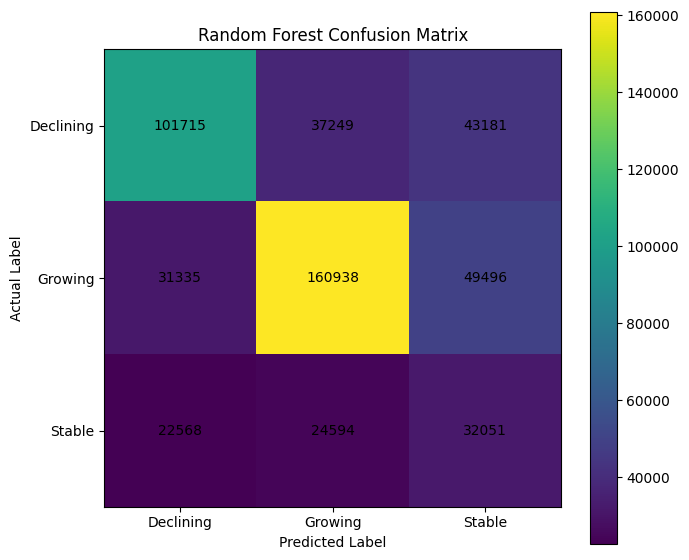

In [74]:
# 4.3 — Random Forest confusion matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=["Declining", "Growing", "Stable"]
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 6))
plt.imshow(cm)

plt.xticks(
    range(3),
    ["Declining", "Growing", "Stable"]
)
plt.yticks(
    range(3),
    ["Declining", "Growing", "Stable"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Confusion Matrix")

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

## 4.4 Confusion Matrix Interpretation

The Random Forest correctly identified 101,715 of the 182,145 Declining observations and 160,938 of the 241,769 Growing observations. Performance was weaker for the Stable class, with 32,051 of 79,213 Stable observations correctly classified.

The main source of error was confusion between neighboring performance trajectories. In particular, some Declining pages were classified as Stable, while some Stable pages were classified as Growing or Declining. This indicates that the model is more effective at separating stronger performance movements than identifying borderline Stable cases.

Because the model is intended as a prioritization tool rather than an automated decision-maker, these results support using its predictions to identify pages for further review rather than treating every prediction as definitive.

,Feature,Importance
3,recent_performance_ratio,0.443592
1,impressions_prev_1m,0.116804
2,avg_impressions_prev_3m,0.063676
0,impressions_prev_3m,0.056629
22,word_count,0.051534
9,clicks_prev_1m,0.048842
21,char_count,0.041411
4,clicks_prev_3m,0.039837
5,sessions_prev_3m,0.018735
19,backlinks,0.016837


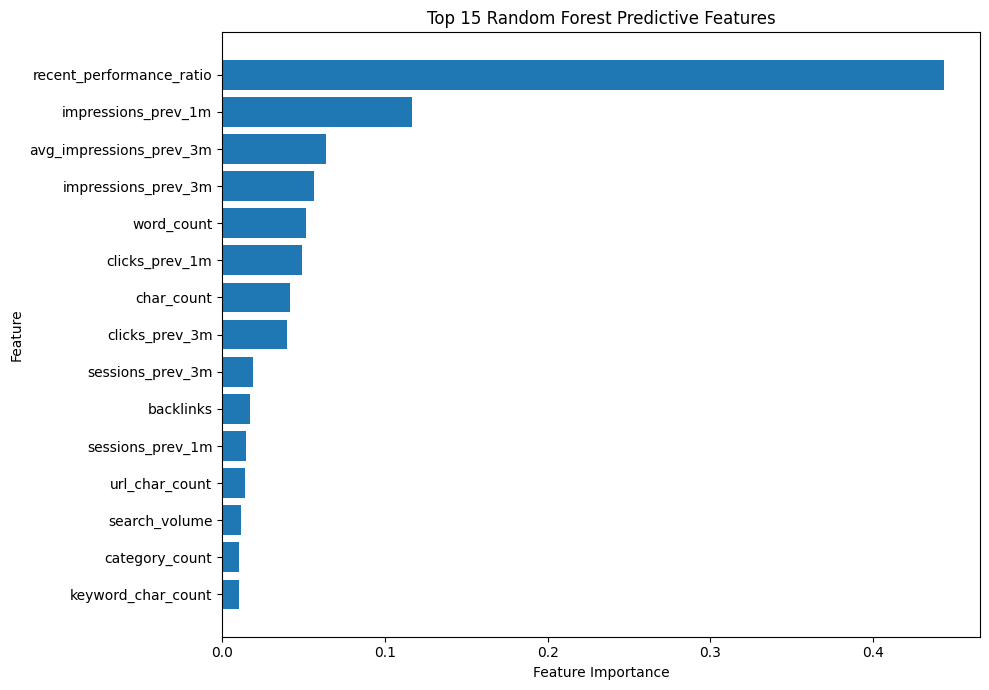

In [75]:
# 4.5 — Random Forest feature importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .head(15)
)

display(feature_importance)

plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"][::-1],
    feature_importance["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Predictive Features")

plt.tight_layout()
plt.show()

## 4.6 Feature Importance Interpretation

The Random Forest feature importance analysis shows that recent page-level performance was the strongest predictive signal. The `recent_performance_ratio` accounted for approximately 44.4% of the model's total feature importance, substantially exceeding the next most important feature, `impressions_prev_1m` at approximately 11.7%.

Other important predictors included the three-month average impressions, total historical impressions, word count, recent clicks, and content character count. Engagement-related measures such as historical sessions and clicks also contributed to the predictions, while search demand, backlinks, category count, and keyword characteristics provided smaller contributions.

These results suggest that recent page-level behavior contains substantial information about subsequent performance trajectory. However, feature importance describes the model's predictive behavior and should not be interpreted as evidence that any individual feature causes future performance changes.

## 5. Limitations

*What this work cannot claim.*


This study has several limitations that should be considered when interpreting the results.

1. **Predictive, not causal:** The models identify statistical patterns associated with future performance trajectories. They do not establish that any feature or content action causes performance changes.

2. **Temporal metadata limitation:** Some content metadata, such as backlinks, search volume, and content characteristics, comes from warehouse-level snapshots rather than fully time-versioned historical records. These variables are therefore treated as descriptive content characteristics rather than guaranteed point-in-time measurements.

3. **Class imbalance and distribution shift:** The target classes are unevenly distributed, and the class distribution changes between the training and test periods. This is reflected in the difference between raw accuracy and balanced accuracy and limits how broadly the results should be generalized.

4. **Stable-class difficulty:** The model has substantially lower predictive performance for the Stable class than for Declining and Growing pages. Predictions near the classification thresholds should therefore be treated with greater uncertainty.

5. **Anonymized data:** Content and client identifiers are anonymized, preventing analysis of specific websites, industries, or identifiable content pages in the public research artifact.

6. **Limited observation period:** The dataset covers a finite historical period from January 2025 through June 2026. Performance patterns may change over time, so the model should be re-evaluated on newer data before operational use.

7. **Decision-support scope:** The model is intended to help prioritize pages for review. It should not be used as an automated replacement for editorial, SEO, or business judgment.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*


The model results support a practical prioritization framework for reviewing content pages. The recommendations below are ranked by the predictive signals identified by the Random Forest and are intended as decision-support actions rather than guaranteed recovery strategies.

### 1. Prioritize pages showing recent performance deterioration
The strongest predictive feature was `recent_performance_ratio`, indicating that recent changes in page-level performance contain substantial information about subsequent trajectory. Pages showing sustained recent deterioration should receive the highest review priority.

### 2. Review recent impressions alongside longer-term performance
Recent impressions and the three-month average were among the next strongest predictors. Comparing recent visibility with the historical baseline can help distinguish temporary variation from a meaningful change in trajectory.

### 3. Investigate changes in clicks and sessions
Recent clicks and historical sessions also contributed to prediction. A decline in impressions accompanied by declining clicks or sessions provides additional evidence that a page should be reviewed.

### 4. Review content depth and structure
Word count and character count were among the more important content-level predictors. Pages identified as at risk can therefore be reviewed for content completeness, organization, relevance, and usefulness rather than relying on length alone.

### 5. Consider authority and demand signals as supporting evidence
Backlinks, search volume, category structure, and keyword characteristics contributed smaller amounts of predictive information. These factors should be used as supporting context rather than as standalone decision rules.

### 6. Use model predictions to prioritize human review
Because the model has difficulty distinguishing Stable pages and does not establish causality, predictions should be treated as prioritization signals. High-priority pages should be reviewed using additional contextual information before any content or SEO intervention is made.

### Recommended workflow

**Detect recent deterioration → Compare with historical baseline → Check clicks and sessions → Review content → Consider demand and authority signals → Human decision**

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

# 7. Artifacts

The final research artifact includes three primary evidence components:

### 7.1 Model Comparison Table

The model comparison reports accuracy and balanced accuracy for the Most Frequent baseline, Random Forest, and XGBoost models on the same time-based test split.

### 7.2 Random Forest Confusion Matrix

The confusion matrix shows how the primary Random Forest model classified Declining, Growing, and Stable performance trajectories and highlights the model's stronger performance on Declining and Growing observations compared with the Stable class.

### 7.3 Random Forest Feature Importance

The feature importance chart shows the relative contribution of the model's predictors. Recent performance ratio is the dominant predictive signal, followed by recent impressions, historical average impressions, and content characteristics.

Together, these artifacts provide evidence for model performance, class-level behavior, and the main predictive signals used to support the recommendations.

# 8. Reproducibility

The analysis was designed to be reproducible from the public FlyRank internship dataset and the code contained in this repository.

### Data
The study uses the `FlyRank/internship-warehouse` dataset hosted on Hugging Face. The analysis uses the daily content-performance table and the content metadata table.

### Prediction design
The prediction task uses the previous three calendar months as the historical reference period and the following prediction month as the outcome period. Pages with fewer than 30 impressions across the previous three months were excluded from target labeling. Performance change was converted into three classes: Declining (≤ −20%), Stable (> −20% and < +20%), and Growing (≥ +20%).

### Validation
A time-based split was used rather than a random split. Observations from May 2025 through January 2026 were used for training, while February 2026 through May 2026 were reserved for testing.

### Models
The study compares a Most Frequent baseline, Random Forest, and XGBoost. The Random Forest was selected as the primary model because it achieved the highest balanced accuracy on the held-out test period.

### Reproducibility controls
The Random Forest and XGBoost experiments use a fixed random seed of 42. Feature construction, target labeling, model training, evaluation, and visualization are contained in the accompanying notebook.

No credentials, private queries, client names, identifying URLs, or raw private exports are included in the public research artifact.

# 9. Acknowledgments & Data Credit

This research was completed as part of the FlyRank ML Internship.

The analysis uses the publicly provided FlyRank internship datasets hosted on Hugging Face, including the `FlyRank/internship-warehouse` dataset. The dataset provides anonymized content-performance, search, engagement, and content metadata used for this study.

I acknowledge FlyRank for providing the dataset and internship framework that made this analysis possible.

All conclusions, interpretations, modeling decisions, and limitations presented in this research are the responsibility of the author.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
